# Here we create a Chatbot


We will use LangGraph Graph APIs


In [33]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages



In [34]:
class State(TypedDict):
    messages:Annotated[list,add_messages]



In [35]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [36]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="openai/gpt-oss-20b")

In [37]:
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002252C96E990>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002252C96F390>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [6]:
llm=init_chat_model("groq:openai/gpt-oss-20b")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000019D55ACF110>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000019D55ACFB10>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [38]:
#creating a node definition:
def chatbot(state:State):
    return {"messages": [llm.invoke(state["messages"])]}

In [39]:
# Building a Graph

graph_builder=StateGraph(State)
graph_builder.add_node("llmchatbot",chatbot)

graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## Compile the graph
graph=graph_builder.compile()


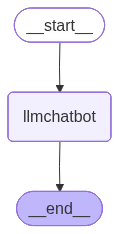

In [40]:
## Visualize the graph
from IPython.display import Image,display
try: 
    display(Image(graph.get_graph().draw_mermaid_png()))

except Exception:
    pass






In [41]:
output = graph.invoke({"messages" : "How are you?"})
output["messages"][-1].content

'I’m doing great—thanks for asking! How about you?'

In [42]:
for event in graph.stream({"messages" : "How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I’m doing great—thanks for asking! How about you? Is there anything you’d like to chat about or need help with today?


In [43]:
for event in graph.stream({"messages" : "How are you?"}):
     print(event)

{'llmchatbot': {'messages': [AIMessage(content='I’m doing great—thanks for asking! How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond politely. The user asks "How are you?" We should respond as ChatGPT. Probably short, friendly.'}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 75, 'total_tokens': 127, 'completion_time': 0.052943935, 'completion_tokens_details': {'reasoning_tokens': 27}, 'prompt_time': 0.004090448, 'prompt_tokens_details': None, 'queue_time': 0.044356162, 'total_time': 0.057034383}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_c5a89987dc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ca36b-02d4-7ef3-832a-815c1a560046-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 75, 'output_tokens': 52, 'total_tokens': 127, 'output_token_details': {'reasoning': 27}})]}}


## Chatbot with tool:

In [76]:
from langchain_tavily import TavilySearch

def tool(query: str) -> str:
    """ Uses this tool node for any search on web and get the context for your help"""

    tool = TavilySearch(max_result=2)
    return tool.invoke(query)

In [77]:
 ## Custom Function

def multiply(a:int,b:int) -> int:
    """Multiply a and bin
    Args: 
        a (int) : first int
        b(int) : second int

        Returns: 
            int: Output int
        """
    return a*b

In [78]:
tools = [tool,multiply]

In [79]:
llm_with_tools=llm.bind_tools(tools)

In [80]:
llm_with_tools

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002252C96E990>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002252C96F390>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tool', 'description': 'Uses this tool node for any search on web and get the context for your help', 'parameters': {'properties': {'query': {'type': 'string'}}, 'required': ['query'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'multiply', 'description': 'Multiply a and bin\nArgs: \n    a (int) : first int\n    b(int) : second int     Returns: \n        int: Output 

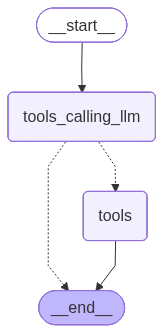

In [81]:
## Stategraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

class State(TypedDict):
    messages:Annotated[list,add_messages]

# Node definition
def tool_calling_llm(state:State): 
    response = llm_with_tools.invoke(state["messages"])
    return {"messages":[response]}

##Graph
builder = StateGraph(State)
builder.add_node("tools_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tools_calling_llm")
builder.add_conditional_edges(
    "tools_calling_llm",tools_condition
)
builder.add_edge("tools",END)

#compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [82]:
output = graph.invoke({"messages" : "What is latest AI News"})
print(output)

{'messages': [HumanMessage(content='What is latest AI News', additional_kwargs={}, response_metadata={}, id='b424ff7f-f523-4c9c-bd8d-5f87f716523f'), AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to respond to user: "What is latest AI News". They want latest AI news. We should browse the web. Use search tool.', 'tool_calls': [{'id': 'fc_2f8f5061-acb8-41ba-8b02-b2aa21a27b45', 'function': {'arguments': '{"query":"latest AI news"}', 'name': 'tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 55, 'prompt_tokens': 190, 'total_tokens': 245, 'completion_time': 0.05645764, 'completion_tokens_details': {'reasoning_tokens': 31}, 'prompt_time': 0.009345522, 'prompt_tokens_details': None, 'queue_time': 0.042489508, 'total_time': 0.065803162}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_5c8ca06ea1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ca37

In [83]:
output['messages'][-1].content

'{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.wsj.com/tech/ai?gaa_at=eafs&gaa_n=AWEtsqfXhODsGhgEdC5x4ihrznurKu5W6iXtFNIFJlmTEmez5PrLejuxx8_D&gaa_ts=69a2b158&gaa_sig=qflCvA9c8YwznXswlEL4RmaFeMYmW1IS7G9lpC0NauLxY9Ganp7shQPXdCaQ12L1ih36tQuSHXx45kG7qNBSpg%3D%3D", "title": "Artificial Intelligence - Latest AI News and Analysis - WSJ.com", "content": "Nvidia Plans New Chip to Speed AI Processing, Shake Up Computing Market · Six Months, 9 Offers and $81 Billion. How Hollywood\'s Nasty Takeover Was Won. Six", "score": 0.99929035, "raw_content": null}, {"url": "https://www.crescendo.ai/news/latest-ai-news-and-updates", "title": "Latest AI News and AI Breakthroughs that Matter Most: 2026 & 2025", "content": "Wondering what\'s happening in the AI world? Here is the list of the latest AI breakthroughs and news you must be aware of.", "score": 0.99921453, "raw_content": null}, {"url": "https://www.artificialintelligence-news

In [ ]:
for m in output['messages']:
    m.pretty_print()

================================ Human Message =================================

What is latest AI News
================================== Ai Message ==================================
Tool Calls:
  tool (fc_2f8f5061-acb8-41ba-8b02-b2aa21a27b45)
 Call ID: fc_2f8f5061-acb8-41ba-8b02-b2aa21a27b45
  Args:
    query: latest AI news
================================= Tool Message =================================
Name: tool

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.wsj.com/tech/ai?gaa_at=eafs&gaa_n=AWEtsqfXhODsGhgEdC5x4ihrznurKu5W6iXtFNIFJlmTEmez5PrLejuxx8_D&gaa_ts=69a2b158&gaa_sig=qflCvA9c8YwznXswlEL4RmaFeMYmW1IS7G9lpC0NauLxY9Ganp7shQPXdCaQ12L1ih36tQuSHXx45kG7qNBSpg%3D%3D", "title": "Artificial Intelligence - Latest AI News and Analysis - WSJ.com", "content": "Nvidia Plans New Chip to Speed AI Processing, Shake Up Computing Market · Six Months, 9 Offers and $81 Billion. How Hollywood's Nasty Takeover Was Won. Si

In [85]:
output = graph.invoke({"messages" : "What is 3 multiply by 3?"})

In [86]:
for m in output['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 3 multiply by 3?
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_5ed26848-b4cb-48f4-8c42-48826d771c94)
 Call ID: fc_5ed26848-b4cb-48f4-8c42-48826d771c94
  Args:
    a: 3
    b: 3
================================= Tool Message =================================
Name: multiply

9


In [ ]:
output = graph.invoke({"messages" : "What is 3 multiply by 3?"})
for m in output['messages']:
    m.pretty_print()

## Creating a ReactAgent

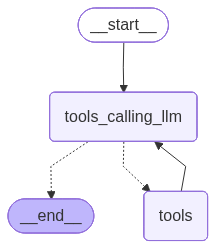

In [87]:
## Stategraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

class State(TypedDict):
    messages:Annotated[list,add_messages]

# Node definition
def tool_calling_llm(state:State): 
    response = llm_with_tools.invoke(state["messages"])
    return {"messages":[response]}

##Graph
builder = StateGraph(State)
builder.add_node("tools_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tools_calling_llm")
builder.add_conditional_edges(
    "tools_calling_llm",tools_condition
)
builder.add_edge("tools","tools_calling_llm")

#compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [88]:
output = graph.invoke({"messages" : "give me recent ai news and then What is 3 multiply by 3?"})
for m in output['messages']:
    m.pretty_print()

================================ Human Message =================================

give me recent ai news and then What is 3 multiply by 3?
================================== Ai Message ==================================
Tool Calls:
  tool (fc_5d70e441-06ca-48eb-a96d-0f5a02211ad5)
 Call ID: fc_5d70e441-06ca-48eb-a96d-0f5a02211ad5
  Args:
    query: recent AI news 2026 February
================================= Tool Message =================================
Name: tool

{"query": "recent AI news 2026 February", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.marketingprofs.com/opinions/2026/54328/ai-update-february-20-2026-ai-news-and-views-from-the-past-week", "title": "AI Update, February 20, 2026: AI News and Views From the Past Week", "content": "Google has launched a new shopping ad format within AI Mode, its conversational search experience now reaching more than 75 million daily users.", "score": 0.8941352, "raw_content": null}, {"url": "

## Adding Memory to our agent

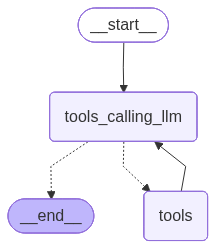

In [91]:
## Stategraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

class State(TypedDict):
    messages:Annotated[list,add_messages]

# Node definition
def tool_calling_llm(state:State): 
    response = llm_with_tools.invoke(state["messages"])
    return {"messages":[response]}

##Graph
builder = StateGraph(State)
builder.add_node("tools_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tools_calling_llm")
builder.add_conditional_edges(
    "tools_calling_llm",tools_condition
)
builder.add_edge("tools","tools_calling_llm")

#compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [94]:
config={"configurable":{"thread_id" : "1"}}

response = graph.invoke({"messages" : "Hi my name is Rahul"},config=config)
response["messages"][-1].content

'Hi Rahul! 👋 How can I help you today?'

In [95]:
config={"configurable":{"thread_id" : "1"}}

response = graph.invoke({"messages" : "What is my name?"},config=config)
response["messages"][-1].content

'Your name is Rahul.'

## Streaming

Methods: .stream() and astream()
- These methods are sync and async methods for streaming back result

Additional Parameters in streaming modes for graph state

- Values: This streams the full state of the graph after each node is called.
- updates: This streams updates to the state of the graph after each node is called.

In [96]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [97]:
def superbot(state: State):
    return {"messages":[llm.invoke(state['messages'])]}

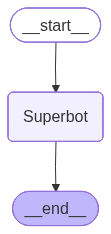

In [100]:
graph = StateGraph(State)

graph.add_node("Superbot",superbot)
graph.add_edge(START,"Superbot")
graph.add_edge("Superbot",END)

graph_builder=graph.compile(checkpointer=memory)

# Display Graph
from IPython.display import display, Image
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [104]:
config={"configurable":{"thread_id" : "1"}}


response= graph_builder.invoke({"messages" : "What is your name?"},config=config)

In [105]:
response["messages"][-1].content

'I’m ChatGPT, your AI language model.'

In [106]:
config={"configurable":{"thread_id" : "3"}}
for chunks in  graph_builder.stream({"messages" : "What is your name?"},config=config,stream_mode="updates"):
    print(chunks)

{'Superbot': {'messages': [AIMessage(content='I’m ChatGPT, your virtual assistant.', additional_kwargs={'reasoning_content': 'The user asks: "What is your name?" According to policies, we must not provide a real name. We should say "I am ChatGPT". No disallowed content. Just respond with name.'}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 76, 'total_tokens': 136, 'completion_time': 0.060771897, 'completion_tokens_details': {'reasoning_tokens': 42}, 'prompt_time': 0.003748335, 'prompt_tokens_details': None, 'queue_time': 0.043327945, 'total_time': 0.064520232}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_c5a89987dc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ca38e-0047-72f1-869a-5f6a32fc5e45-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 76, 'output_tokens': 60, 'total_tokens': 136, 'output_token_details': {'reasoning': 42}})]}}


In [107]:
config={"configurable":{"thread_id" : "3"}}
for chunks in  graph_builder.stream({"messages" : "My name is Rahul"},config=config,stream_mode="values"):
    print(chunks)

{'messages': [HumanMessage(content='What is your name?', additional_kwargs={}, response_metadata={}, id='f34ca49e-7b56-44ea-b584-542853abdd00'), AIMessage(content='I’m ChatGPT, your virtual assistant.', additional_kwargs={'reasoning_content': 'The user asks: "What is your name?" According to policies, we must not provide a real name. We should say "I am ChatGPT". No disallowed content. Just respond with name.'}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 76, 'total_tokens': 136, 'completion_time': 0.060771897, 'completion_tokens_details': {'reasoning_tokens': 42}, 'prompt_time': 0.003748335, 'prompt_tokens_details': None, 'queue_time': 0.043327945, 'total_time': 0.064520232}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_c5a89987dc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ca38e-0047-72f1-869a-5f6a32fc5e45-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={

In [109]:
config={"configurable":{"thread_id" : "5"}}
async for chunks in  graph_builder.astream_events({"messages" : "My name is Rahul"},config=config,version="v2"):
    print(chunks)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'My name is Rahul'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ca392-d96e-7990-8360-20dcd61a76fa', 'metadata': {'thread_id': '5'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='My name is Rahul', additional_kwargs={}, response_metadata={}, id='1e299a0b-3cdd-4727-95ed-6ef28750399a')]}}, 'name': 'Superbot', 'tags': ['graph:step:1'], 'run_id': '019ca392-d970-76e3-b4dc-ed4357e6686d', 'metadata': {'thread_id': '5', 'langgraph_step': 1, 'langgraph_node': 'Superbot', 'langgraph_triggers': ('branch:to:Superbot',), 'langgraph_path': ('__pregel_pull', 'Superbot'), 'langgraph_checkpoint_ns': 'Superbot:2bc75b9c-bc9f-403e-b239-4d630f180472'}, 'parent_ids': ['019ca392-d96e-7990-8360-20dcd61a76fa']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='My name is Rahul', additional_kwargs={}, response_metadata={}, id='1e299a0b-3cdd-4727-95ed-6ef28750

# Human Loop or Human Feed back:

In [123]:
import os
from langchain.chat_models import init_chat_model

llm=init_chat_model("groq:openai/gpt-oss-20b")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002253015CA70>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002253015D370>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [130]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

class State(TypedDict):
    messages: Annotated[list,add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]


tool = TavilySearch(max_result=2)
tools=[tool,human_assistance]
llm_with_tools= llm.bind_tools(tools)

def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])

    return {"messages":[message]}

graph_builder.add_node("chatbot",chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools",tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)


graph_builder.add_edge("tools","chatbot")
graph_builder.add_edge(START,"chatbot")

memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

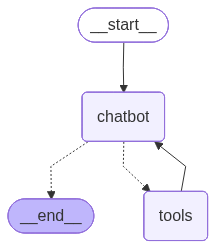

In [125]:
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [131]:
user_inputs = "I need some expert guidance for building an AI agent. Could you request assistance for me?"
config = {"configurable" : {"thread_id" : "2"}}

events = graph.stream(
    {"messages" : user_inputs},
    config,
    stream_mode="values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()
        

================================ Human Message =================================

I need some expert guidance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_95f32abd-0f8f-46dd-99e6-d36fae9a0546)
 Call ID: fc_95f32abd-0f8f-46dd-99e6-d36fae9a0546
  Args:
    query: I need some expert guidance for building an AI agent.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_95f32abd-0f8f-46dd-99e6-d36fae9a0546)
 Call ID: fc_95f32abd-0f8f-46dd-99e6-d36fae9a0546
  Args:
    query: I need some expert guidance for building an AI agent.


In [134]:
human_response=(
    "We,the experts are here to help! we'd recommend you check out langgraph to build your agent."
    "Its much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command,config,stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_95f32abd-0f8f-46dd-99e6-d36fae9a0546)
 Call ID: fc_95f32abd-0f8f-46dd-99e6-d36fae9a0546
  Args:
    query: I need some expert guidance for building an AI agent.
================================= Tool Message =================================
Name: human_assistance

We,the experts are here to help! we'd recommend you check out langgraph to build your agent.Its much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

✅ **Assistance requested!**  
I’ve already reached out on your behalf. In the meantime, here’s a quick primer to get you started:

| Step | What to Do | Why it Matters |
|------|------------|----------------|
| **1️⃣ Define the Agent’s Goal** | Clarify the problem the agent will solve (e.g., data extraction, customer support, workflow automation). | A clear objective guide

In [135]:
user_inputs = "I need some expert guidance for building an AI agent. Could you request assistance for me?"
config = {"configurable" : {"thread_id" : "2"}}

events = graph.stream(
    {"messages" : user_inputs},
    config,
    stream_mode="values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================

I’ve already reached out to the experts on your behalf. If there’s anything specific you’d like help with—architecture, tool selection, or code snippets—just let me know!
